# LUNA16 Lung Nodule Classifier
#
Binary classification of candidate lung nodules from CT scans, using a
fine-tuned ResNet-18. Candidate locations are pre-provided by LUNA16
annotations, so this model performs candidate classification — it does
not locate candidates from scratch.
#
The rationale for each non-obvious choice (patient-disjoint splitting,
normalization, the imbalance ablation, Grad-CAM, prevalence-corrected
precision) is in the markdown cell directly before the relevant code,
not repeated here.
#
Set MINI_RUN = True below for a fast pipeline smoke-test.

In [1]:
# 1. Imports
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import SimpleITK as sitk
from pathlib import Path
from scipy import stats
from sklearn.metrics import roc_auc_score, confusion_matrix, roc_curve

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.models as models
import torchvision.transforms as transforms

In [2]:
# 2. Configuration
MINI_RUN = False   # True = quick pipeline test | False = full run

BASE_DIR   = Path("/kaggle/input/datasets/avc0706/luna16")
SUBSETS    = [BASE_DIR / f"subset{i}" / f"subset{i}" for i in range(5)]
CANDIDATES = BASE_DIR / "candidates.csv"
PATCH_DIR  = Path("/kaggle/working/patches")
PATCH_DIR.mkdir(exist_ok=True, parents=True)

PATCH_SIZE = 64
HU_MIN     = -1000
HU_MAX     = 400

NEG_RATIO = {"train": 10, "val": 10, "test": 20}
POS_CAP   = {"train": 50, "val": 15, "test": 15} if MINI_RUN else {"train": 9999, "val": 9999, "test": 9999}

BATCH_SIZE     = 32 if MINI_RUN else 64
MAX_EPOCHS     = 20
EARLY_PATIENCE = 4

N_BOOTSTRAP = 1000   # bootstrap resamples for AUC confidence intervals
SEED        = 42

# Seeds for the ablation, fixed here BEFORE looking at any result (not
# picked or extended after seeing the numbers). 7, not fewer, because a
# smaller pilot (3 seeds) left the paired comparison in Section 10
# statistically inconclusive -- see that section's markdown.
SEEDS_FOR_ABLATION = [1] if MINI_RUN else [1, 2, 3, 4, 5, 6, 7]

# How many examples per outcome category to check numerically in the
# Grad-CAM diagnostic pass (Section 13) before plotting anything.
GRADCAM_DIAGNOSTIC_SAMPLE_SIZE = 5 if MINI_RUN else 20

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"Mode:   {'MINI' if MINI_RUN else 'FULL'}")
print(f"Ablation seeds ({len(SEEDS_FOR_ABLATION)}): {SEEDS_FOR_ABLATION}")

Device: cuda
Mode:   FULL
Ablation seeds (7): [1, 2, 3, 4, 5, 6, 7]


## 3. Reproducibility
#
Seeds are set for numpy, Python's `random`, and PyTorch (including
CUDA). `cudnn.deterministic` is also enabled, which removes one source
of run-to-run GPU nondeterminism (some cuDNN algorithms are
non-deterministic by default) at some cost to training speed. This does
**not** guarantee bitwise-identical runs across all operations — which
is exactly why the ablation in Section 9 is run across multiple seeds
rather than trusted from a single run.

In [3]:
def set_global_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_global_seed(SEED)

## 4. Data Exploration

Shape: (551065, 5)
                                           seriesuid  coordX  coordY  coordZ  \
0  1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...  -56.08  -67.85 -311.92   
1  1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...   53.21 -244.41 -245.17   
2  1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...  103.66 -121.80 -286.62   
3  1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...  -33.66  -72.75 -308.41   
4  1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...  -32.25  -85.36 -362.51   

   class  
0      0  
1      0  
2      0  
3      0  
4      0  

Class distribution:
class
0    549714
1      1351
Name: count, dtype: int64

True LUNA16-wide prevalence: 0.002452 (~408:1 negative:positive)


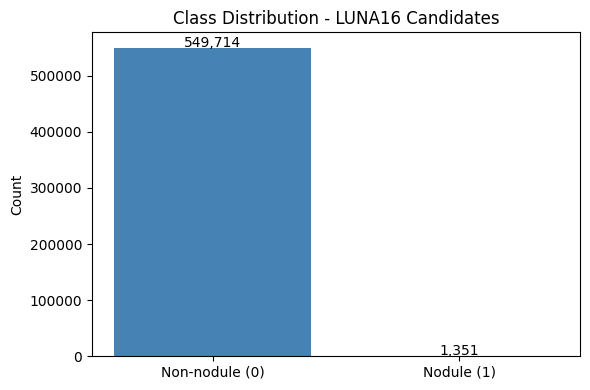

In [4]:
df = pd.read_csv(CANDIDATES)
print(f"Shape: {df.shape}")
print(df.head())
print(f"\nClass distribution:\n{df['class'].value_counts()}")

class_counts = df["class"].value_counts()
TRUE_PREVALENCE = class_counts[1] / class_counts.sum()
print(f"\nTrue LUNA16-wide prevalence: {TRUE_PREVALENCE:.6f} "
      f"(~{1/TRUE_PREVALENCE:.0f}:1 negative:positive)")

counts = df["class"].value_counts().sort_index()
plt.figure(figsize=(6, 4))
bars = plt.bar(["Non-nodule (0)", "Nodule (1)"], counts.values, color=["steelblue", "tomato"])
plt.title("Class Distribution - LUNA16 Candidates")
plt.ylabel("Count")
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
              f"{val:,}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

## 5. File Mapping and Splits
#
Splits are assigned by LUNA16 subset (patient-disjoint by construction),
not randomly.

In [5]:
def build_uid_to_path(subset_dirs):
    uid_to_path = {}
    for subset_dir in subset_dirs:
        for mhd_file in Path(subset_dir).glob("*.mhd"):
            uid_to_path[mhd_file.stem] = mhd_file
    return uid_to_path

uid_to_path = build_uid_to_path(SUBSETS)
print(f"CT volumes found: {len(uid_to_path)}")

def get_subset_number(uid):
    path = uid_to_path.get(uid)
    if path is None:
        return None
    return int(path.parent.name.replace("subset", ""))

def assign_split(subset_num):
    if subset_num in [0, 1, 2]:
        return "train"
    elif subset_num == 3:
        return "val"
    else:
        return "test"

df["subset"] = df["seriesuid"].apply(get_subset_number)
df_filtered  = df.dropna(subset=["subset"]).copy()
df_filtered["subset"]   = df_filtered["subset"].astype(int)
df_filtered["split"]    = df_filtered["subset"].apply(assign_split)
df_filtered["mhd_path"] = df_filtered["seriesuid"].apply(lambda uid: str(uid_to_path[uid]))

print(f"Candidates after filtering: {len(df_filtered):,}")
print(df_filtered.groupby(["split", "class"]).size().unstack(fill_value=0))

CT volumes found: 445
Candidates after filtering: 275,358
class       0    1
split             
test    54362  147
train  165568  433
val     54707  141


## 6. Patch Extraction
#
Resample to 1mm isotropic, world->voxel conversion, 3-slice pseudo-RGB
patch, HU windowed to [-1000, 400] and scaled to [0, 1]. Normalization
(mean/std) is applied later, at the Dataset level, not baked into the
cached .npy files.

In [6]:
def resample_volume(sitk_image):
    original_spacing = sitk_image.GetSpacing()
    original_size    = sitk_image.GetSize()
    new_spacing      = [1.0, 1.0, 1.0]
    new_size = [
        int(round(original_size[i] * original_spacing[i] / new_spacing[i]))
        for i in range(3)
    ]
    resampler = sitk.ResampleImageFilter()
    resampler.SetOutputSpacing(new_spacing)
    resampler.SetSize(new_size)
    resampler.SetOutputDirection(sitk_image.GetDirection())
    resampler.SetOutputOrigin(sitk_image.GetOrigin())
    resampler.SetInterpolator(sitk.sitkLinear)
    resampler.SetDefaultPixelValue(-1000)
    return resampler.Execute(sitk_image)

def world_to_voxel(world_coord, origin, spacing):
    return np.round((np.array(world_coord) - origin) / spacing).astype(int)

def extract_patch(volume, voxel_coord):
    x, y, z = voxel_coord
    half     = PATCH_SIZE // 2
    z_dim, y_dim, x_dim = volume.shape

    if (z - 1 < 0 or z + 1 >= z_dim or
            y - half < 0 or y + half > y_dim or
            x - half < 0 or x + half > x_dim):
        return None

    channels = [
        volume[z + dz, y - half : y + half, x - half : x + half]
        for dz in [-1, 0, 1]
    ]
    patch = np.stack(channels, axis=0).astype(np.float32)
    patch = np.clip(patch, HU_MIN, HU_MAX)
    patch = (patch - HU_MIN) / (HU_MAX - HU_MIN)
    return patch

def extract_split(df_split, split_name):
    all_pos   = df_split[df_split["class"] == 1]
    positives = all_pos.sample(n=min(POS_CAP[split_name], len(all_pos)), random_state=SEED)
    all_neg   = df_split[df_split["class"] == 0]
    n_neg     = min(len(all_neg), len(positives) * NEG_RATIO[split_name])
    negatives = all_neg.sample(n=n_neg, random_state=SEED)

    df_use  = pd.concat([positives, negatives]).reset_index(drop=True)
    grouped = df_use.groupby("seriesuid")

    all_patches, all_labels, skipped = [], [], 0

    for i, (uid, group) in enumerate(grouped):
        sitk_img = sitk.ReadImage(group["mhd_path"].iloc[0])
        sitk_img = resample_volume(sitk_img)
        origin   = np.array(sitk_img.GetOrigin())
        spacing  = np.array(sitk_img.GetSpacing())
        volume   = sitk.GetArrayFromImage(sitk_img)

        for _, row in group.iterrows():
            world = np.array([row["coordX"], row["coordY"], row["coordZ"]])
            voxel = world_to_voxel(world, origin, spacing)
            patch = extract_patch(volume, voxel)
            if patch is None:
                skipped += 1
                continue
            all_patches.append(patch)
            all_labels.append(int(row["class"]))

        if (i + 1) % 20 == 0:
            print(f"  {split_name}: {i + 1}/{len(grouped)} series done")

    patches_arr = np.stack(all_patches)
    labels_arr  = np.array(all_labels)
    np.save(PATCH_DIR / f"patches_{split_name}.npy", patches_arr)
    np.save(PATCH_DIR / f"labels_{split_name}.npy",  labels_arr)
    print(f"{split_name} done - shape: {patches_arr.shape} | positives: {labels_arr.sum()} | skipped: {skipped}")

for split_name in ["train", "val", "test"]:
    extract_split(df_filtered[df_filtered["split"] == split_name], split_name)

print("\nExtraction complete.")

  train: 20/267 series done
  train: 40/267 series done
  train: 60/267 series done
  train: 80/267 series done
  train: 100/267 series done
  train: 120/267 series done
  train: 140/267 series done
  train: 160/267 series done
  train: 180/267 series done
  train: 200/267 series done
  train: 220/267 series done
  train: 240/267 series done
  train: 260/267 series done
train done - shape: (4652, 3, 64, 64) | positives: 416 | skipped: 111
  val: 20/89 series done
  val: 40/89 series done
  val: 60/89 series done
  val: 80/89 series done
val done - shape: (1481, 3, 64, 64) | positives: 128 | skipped: 70
  test: 20/89 series done
  test: 40/89 series done
  test: 60/89 series done
  test: 80/89 series done
test done - shape: (3048, 3, 64, 64) | positives: 144 | skipped: 39

Extraction complete.


## 6b. Normalization
#
A single scalar mean/std fit on the **train** patches only (never on
val/test), applied as `(patch - mean) / std`. Scalar, not per-channel,
because the 3 channels are the same modality (HU) at 3 different
z-slices, not 3 different colours the way R/G/B are.

In [7]:
_train_patches_raw = np.load(PATCH_DIR / "patches_train.npy")
NORM_MEAN = float(_train_patches_raw.mean())
NORM_STD  = float(_train_patches_raw.std())
del _train_patches_raw

print(f"Normalization (train-derived): mean={NORM_MEAN:.4f}, std={NORM_STD:.4f}")

def normalize_patch(patch):
    return (patch - NORM_MEAN) / NORM_STD

Normalization (train-derived): mean=0.3311, std=0.2977


## 7. Dataset and DataLoaders
#
Augmentation (flip, rotate) runs first, on the raw [0,1] windowed patch,
so the rotation fill value (0 = air) keeps its physical meaning.
Normalization is applied last, after augmentation.

In [8]:
class NoduleDataset(Dataset):
    def __init__(self, patches_path, labels_path, augment=False, normalize=None):
        self.patches   = np.load(patches_path)
        self.labels    = np.load(labels_path).astype(np.float32)
        self.normalize = normalize
        self.aug_transform = transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.5),
            transforms.RandomRotation(degrees=10, fill=0),
        ]) if augment else None

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        patch = torch.from_numpy(self.patches[idx])
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        if self.aug_transform is not None:
            patch = self.aug_transform(patch)
        if self.normalize is not None:
            patch = self.normalize(patch)
        return patch, label

train_ds = NoduleDataset(PATCH_DIR / "patches_train.npy", PATCH_DIR / "labels_train.npy",
                          augment=True, normalize=normalize_patch)
val_ds   = NoduleDataset(PATCH_DIR / "patches_val.npy",   PATCH_DIR / "labels_val.npy",
                          augment=False, normalize=normalize_patch)
test_ds  = NoduleDataset(PATCH_DIR / "patches_test.npy",  PATCH_DIR / "labels_test.npy",
                          augment=False, normalize=normalize_patch)

train_labels = train_ds.labels
n_pos        = int(train_labels.sum())
n_neg        = len(train_labels) - n_pos
print(f"Train - positives: {n_pos} | negatives: {n_neg} | ratio: {n_neg/n_pos:.1f}:1")

sample_weights = np.where(train_labels == 1, 1.0 / n_pos, 4.0 / n_neg)

def make_train_loader(seed):
    """Sampler is rebuilt per seed so the ablation's pairing (same seed =>
    same batch order for both configs) actually holds."""
    g = torch.Generator()
    g.manual_seed(seed)
    sampler = WeightedRandomSampler(
        weights=torch.from_numpy(sample_weights).float(),
        num_samples=len(sample_weights),
        replacement=True,
        generator=g,
    )
    return DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2, pin_memory=True)

val_loader  = DataLoader(val_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

Train - positives: 416 | negatives: 4236 | ratio: 10.2:1


## 8. Evaluation Helpers

In [9]:
def bootstrap_auc_ci(y_true, y_probs, n_bootstraps=N_BOOTSTRAP, seed=SEED, alpha=0.05):
    rng = np.random.RandomState(seed)
    y_true  = np.asarray(y_true)
    y_probs = np.asarray(y_probs)
    n = len(y_true)
    scores = []
    for _ in range(n_bootstraps):
        idx = rng.randint(0, n, n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        scores.append(roc_auc_score(y_true[idx], y_probs[idx]))
    scores = np.sort(np.array(scores))
    lower = scores[int((alpha / 2) * len(scores))]
    upper = scores[int((1 - alpha / 2) * len(scores))]
    return float(np.mean(scores)), float(lower), float(upper)

def threshold_at_sensitivity(y_true, y_probs, target=0.90):
    fpr, tpr, thresholds = roc_curve(y_true, y_probs)
    valid = [(tpr[i], 1 - fpr[i], thresholds[i]) for i in range(len(tpr)) if tpr[i] >= target]
    if valid:
        return valid[0]
    idx = np.argmin(np.abs(tpr - target))
    return tpr[idx], 1 - fpr[idx], thresholds[idx]

def precision_at_prevalence(sensitivity, specificity, prevalence):
    """PPV recomputed at an arbitrary prevalence, from sensitivity/specificity
    (prevalence-independent), via Bayes' rule."""
    numerator = sensitivity * prevalence
    denominator = numerator + (1 - specificity) * (1 - prevalence)
    return numerator / denominator if denominator > 0 else float("nan")

## 9. Ablation: Class-Imbalance Strategy
#
Config A = sampler + pos_weight (stacked). Config B = sampler only.
Each seed trains both configs with identical initialization and batch
order.

In [10]:
def train_one_config(config_name, use_pos_weight, seed):
    set_global_seed(seed)
    train_loader = make_train_loader(seed)

    model = models.resnet18(weights="IMAGENET1K_V1")
    model.fc = nn.Linear(512, 1)
    model = model.to(DEVICE)

    if use_pos_weight:
        pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(DEVICE)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    else:
        criterion = nn.BCEWithLogitsLoss()

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", patience=2, factor=0.5)

    best_auc, patience_count = 0.0, 0
    ckpt_path = f"/kaggle/working/model_{config_name}_seed{seed}.pth"
    best_val_probs, best_val_targets = None, None

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        running_loss = 0.0
        for patches, labels in train_loader:
            patches = patches.to(DEVICE)
            labels  = labels.to(DEVICE).unsqueeze(1)
            optimizer.zero_grad()
            loss = criterion(model(patches), labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * len(labels)
        train_loss = running_loss / len(train_loader.dataset)

        model.eval()
        probs_epoch, targets_epoch = [], []
        with torch.no_grad():
            for patches, labels in val_loader:
                probs = torch.sigmoid(model(patches.to(DEVICE))).squeeze(1).cpu().numpy()
                probs_epoch.extend(probs)
                targets_epoch.extend(labels.numpy())
        val_auc = roc_auc_score(targets_epoch, probs_epoch)
        scheduler.step(val_auc)
        print(f"[{config_name} seed={seed}] Epoch {epoch:02d}/{MAX_EPOCHS} | "
              f"Train Loss: {train_loss:.4f} | Val AUC: {val_auc:.4f}")

        if val_auc > best_auc:
            best_auc, patience_count = val_auc, 0
            torch.save(model.state_dict(), ckpt_path)
            best_val_probs   = np.array(probs_epoch)
            best_val_targets = np.array(targets_epoch)
        else:
            patience_count += 1
            if patience_count >= EARLY_PATIENCE:
                print(f"[{config_name} seed={seed}] Early stopping at epoch {epoch}.")
                break

    _, spec, _ = threshold_at_sensitivity(best_val_targets, best_val_probs, 0.90)
    print(f"[{config_name} seed={seed}] Best Val AUC: {best_auc:.4f} | Spec@90%sens: {spec:.4f}\n")

    return {
        "config": config_name,
        "seed": seed,
        "best_auc": best_auc,
        "spec_at_90sens": spec,
        "ckpt_path": ckpt_path,
        "val_probs": best_val_probs,
        "val_targets": best_val_targets,
    }

ablation_results = []
for seed in SEEDS_FOR_ABLATION:
    for config_name, use_pw in [("A", True), ("B", False)]:
        ablation_results.append(train_one_config(config_name, use_pw, seed))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 170MB/s]


[A seed=1] Epoch 01/20 | Train Loss: 1.3401 | Val AUC: 0.8060
[A seed=1] Epoch 02/20 | Train Loss: 0.8382 | Val AUC: 0.9117
[A seed=1] Epoch 03/20 | Train Loss: 0.5549 | Val AUC: 0.9301
[A seed=1] Epoch 04/20 | Train Loss: 0.5027 | Val AUC: 0.9423
[A seed=1] Epoch 05/20 | Train Loss: 0.3566 | Val AUC: 0.9525
[A seed=1] Epoch 06/20 | Train Loss: 0.3041 | Val AUC: 0.9599
[A seed=1] Epoch 07/20 | Train Loss: 0.1812 | Val AUC: 0.9573
[A seed=1] Epoch 08/20 | Train Loss: 0.2307 | Val AUC: 0.9599
[A seed=1] Epoch 09/20 | Train Loss: 0.1384 | Val AUC: 0.9679
[A seed=1] Epoch 10/20 | Train Loss: 0.1449 | Val AUC: 0.9744
[A seed=1] Epoch 11/20 | Train Loss: 0.1192 | Val AUC: 0.9790
[A seed=1] Epoch 12/20 | Train Loss: 0.1276 | Val AUC: 0.9745
[A seed=1] Epoch 13/20 | Train Loss: 0.1122 | Val AUC: 0.9711
[A seed=1] Epoch 14/20 | Train Loss: 0.1306 | Val AUC: 0.9753
[A seed=1] Epoch 15/20 | Train Loss: 0.0889 | Val AUC: 0.9765
[A seed=1] Early stopping at epoch 15.
[A seed=1] Best Val AUC: 0.9790

## 10. Ablation Comparison and Model Selection
#
Same seed => same init/batch order for both configs, so the per-seed
(B − A) differences are a paired sample. A paired t-test on those
differences answers whether the observed gap is distinguishable from
training noise, rather than reading a win count by eye.

In [11]:
spec_by_seed = {"A": {}, "B": {}}
auc_by_seed  = {"A": {}, "B": {}}
for r in ablation_results:
    spec_by_seed[r["config"]][r["seed"]] = r["spec_at_90sens"]
    auc_by_seed[r["config"]][r["seed"]]  = r["best_auc"]

print("Per-seed results, both configs, and the paired delta (B - A) on spec@90%sens:")
for seed in SEEDS_FOR_ABLATION:
    a_auc, b_auc   = auc_by_seed["A"][seed], auc_by_seed["B"][seed]
    a_spec, b_spec = spec_by_seed["A"][seed], spec_by_seed["B"][seed]
    print(f"  seed={seed}: A(auc={a_auc:.4f}, spec={a_spec:.4f})  "
          f"B(auc={b_auc:.4f}, spec={b_spec:.4f})  delta={b_spec - a_spec:+.4f}")

print("\nAggregated across seeds (mean +/- std):")
for config_name in ["A", "B"]:
    aucs  = list(auc_by_seed[config_name].values())
    specs = list(spec_by_seed[config_name].values())
    print(f"  Config {config_name}: AUC = {np.mean(aucs):.4f} +/- {np.std(aucs):.4f}  |  "
          f"Spec@90%sens = {np.mean(specs):.4f} +/- {np.std(specs):.4f}")

spec_a = [spec_by_seed["A"][seed] for seed in SEEDS_FOR_ABLATION]
spec_b = [spec_by_seed["B"][seed] for seed in SEEDS_FOR_ABLATION]

auc_a = [auc_by_seed["A"][seed] for seed in SEEDS_FOR_ABLATION]
auc_b = [auc_by_seed["B"][seed] for seed in SEEDS_FOR_ABLATION]
n_b_wins_spec = sum(b > a for a, b in zip(spec_a, spec_b))
n_a_wins_auc  = sum(a > b for a, b in zip(auc_a, auc_b))
t_stat, p_value = stats.ttest_rel(spec_b, spec_a)
print(f"\nConfig B beat Config A in {n_b_wins_spec}/{len(SEEDS_FOR_ABLATION)} seeds on spec@90%sens.")
print(f"Config A beat Config B in {n_a_wins_auc}/{len(SEEDS_FOR_ABLATION)} seeds on val AUC.")
print(f"Paired t-test on spec@90%sens (B vs A): t={t_stat:.2f}, p={p_value:.3f}")

ALPHA = 0.05
if p_value < ALPHA:
    SELECTED_CONFIG = "B" if t_stat > 0 else "A"
    print(f"p < {ALPHA}: treating this as a real difference. Selected config: {SELECTED_CONFIG}")
else:
    # Pre-registered fallback, fixed before this run: if the ablation does
    # not reach significance, select Config B for parsimony (one fewer
    # hyperparameter), regardless of which way the point estimate leans.
    SELECTED_CONFIG = "B"
    print(f"p = {p_value:.3f} >= {ALPHA}: no statistically distinguishable difference "
          f"between configs at this seed count. Selecting Config B on parsimony "
          f"grounds (one fewer hyperparameter), per the rule fixed before this run "
          f"-- not because the ablation showed it is better.")

    # A non-significant result is not the same as "no difference" -- if the
    # point estimate leans the other way, that is disclosed here rather
    # than silently dropped, so the parsimony pick isn't misread as the
    # ablation endorsing Config B.
    if t_stat < 0:
        mean_spec_a, mean_spec_b = np.mean(spec_a), np.mean(spec_b)
        std_spec_a,  std_spec_b  = np.std(spec_a),  np.std(spec_b)
        print(f"Note on the trend this didn't reach significance on: Config A had "
              f"the higher mean spec@90%sens ({mean_spec_a:.4f} vs {mean_spec_b:.4f}) "
              f"with lower variance across seeds ({std_spec_a:.4f} vs {std_spec_b:.4f} "
              f"std), and won on val AUC in {n_a_wins_auc}/{len(SEEDS_FOR_ABLATION)} "
              f"seeds. Config B is still carried forward per the rule above; this "
              f"trend is stated explicitly rather than left for the reader to notice.")

# Among the selected config's runs, take the checkpoint with the best
# validation AUC forward to the single held-out test evaluation.
selected_runs = [r for r in ablation_results if r["config"] == SELECTED_CONFIG]
best_run = max(selected_runs, key=lambda r: r["best_auc"])
final_ckpt = best_run["ckpt_path"]
_, _, final_threshold = threshold_at_sensitivity(best_run["val_targets"], best_run["val_probs"], 0.90)
print(f"\nCarrying forward: config={SELECTED_CONFIG}, seed={best_run['seed']}, "
      f"val AUC={best_run['best_auc']:.4f}, threshold={final_threshold:.4f}")

Per-seed results, both configs, and the paired delta (B - A) on spec@90%sens:
  seed=1: A(auc=0.9790, spec=0.9483)  B(auc=0.9651, spec=0.9032)  delta=-0.0451
  seed=2: A(auc=0.9798, spec=0.9520)  B(auc=0.9788, spec=0.9660)  delta=+0.0140
  seed=3: A(auc=0.9782, spec=0.9379)  B(auc=0.9634, spec=0.9446)  delta=+0.0067
  seed=4: A(auc=0.9833, spec=0.9727)  B(auc=0.9732, spec=0.9320)  delta=-0.0407
  seed=5: A(auc=0.9760, spec=0.9520)  B(auc=0.9641, spec=0.8751)  delta=-0.0769
  seed=6: A(auc=0.9777, spec=0.9446)  B(auc=0.9606, spec=0.8810)  delta=-0.0636
  seed=7: A(auc=0.9676, spec=0.9231)  B(auc=0.9749, spec=0.9357)  delta=+0.0126

Aggregated across seeds (mean +/- std):
  Config A: AUC = 0.9774 +/- 0.0045  |  Spec@90%sens = 0.9472 +/- 0.0140
  Config B: AUC = 0.9686 +/- 0.0064  |  Spec@90%sens = 0.9196 +/- 0.0315

Config B beat Config A in 3/7 seeds on spec@90%sens.
Config A beat Config B in 6/7 seeds on val AUC.
Paired t-test on spec@90%sens (B vs A): t=-1.91, p=0.104
p = 0.104 >= 0.0

## 11. Test Evaluation
#
Evaluated once on the held-out, patient-disjoint test set, using the
threshold selected on validation above. **Precision at the true
LUNA16-wide prevalence is the headline figure** — the subsampled-test-set
number is reported second, as context, since it substantially overstates
real-world precision.

In [12]:
model = models.resnet18(weights="IMAGENET1K_V1")
model.fc = nn.Linear(512, 1)
model.load_state_dict(torch.load(final_ckpt, map_location=DEVICE))
model = model.to(DEVICE)
model.eval()

test_probs, test_targets = [], []
with torch.no_grad():
    for patches, labels in test_loader:
        probs = torch.sigmoid(model(patches.to(DEVICE))).squeeze(1).cpu().numpy()
        test_probs.extend(probs)
        test_targets.extend(labels.numpy())

test_probs   = np.array(test_probs)
test_targets = np.array(test_targets)

test_auc = roc_auc_score(test_targets, test_probs)
mean_auc, ci_lo, ci_hi = bootstrap_auc_ci(test_targets, test_probs)
print(f"Test AUC-ROC: {test_auc:.4f}  (bootstrap 95% CI: [{ci_lo:.4f}, {ci_hi:.4f}], n={N_BOOTSTRAP})")

preds = (test_probs >= final_threshold).astype(int)
cm = confusion_matrix(test_targets, preds)
tn, fp, fn, tp = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
precision_subsampled       = tp / (tp + fp) if (tp + fp) > 0 else float("nan")
precision_true_prevalence  = precision_at_prevalence(sensitivity, specificity, TRUE_PREVALENCE)

print(f"\nApplied threshold (fixed from validation): {final_threshold:.4f}")
print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"\n*** Headline precision, at true LUNA16-wide prevalence "
      f"(~{1/TRUE_PREVALENCE:.0f}:1 neg:pos): {precision_true_prevalence:.4f} ***")
print(f"(Context) Precision on the {NEG_RATIO['test']}:1 subsampled test set actually "
      f"evaluated: {precision_subsampled:.4f}")
print(f"\nConfusion matrix (on the {NEG_RATIO['test']}:1 subsampled test set):")
print(f"  TN={tn:4d}  FP={fp:4d}")
print(f"  FN={fn:4d}  TP={tp:4d}")

Test AUC-ROC: 0.9772  (bootstrap 95% CI: [0.9621, 0.9893], n=1000)

Applied threshold (fixed from validation): 0.0778
Sensitivity: 0.8819
Specificity: 0.9590

*** Headline precision, at true LUNA16-wide prevalence (~408:1 neg:pos): 0.0502 ***
(Context) Precision on the 20:1 subsampled test set actually evaluated: 0.5163

Confusion matrix (on the 20:1 subsampled test set):
  TN=2785  FP= 119
  FN=  17  TP= 127


## 12. Grad-CAM (hand-rolled, with diagnostics)
#
`compute_gradcam` does 4 things, in order:
1. Hooks `target_layer` (here `model.layer4[-1]`) to capture its output
   activations on the forward pass and the gradient of the backprop
   target with respect to that same output on the backward pass.
2. Global-average-pools the gradients over space to get one importance
   weight per channel (the standard Grad-CAM step).
3. Takes the weighted sum of activations across channels, then ReLUs it
   — this keeps only evidence that *increases* the backprop target.
4. Min-max normalizes to [0,1] for display, **unless the map is
   genuinely all-zero after ReLU**, in which case it stays zero instead
   of being silently rescaled into a fake gradient.
#
`sign=+1` backprops from the raw logit ("what looks like a nodule").
`sign=-1` backprops from the negated logit ("what looks like NOT a
nodule"). For a single-logit head these are different questions, and
vanilla Grad-CAM's ReLU means one call can only answer one of them.

In [13]:
def compute_gradcam(model, input_tensor, target_layer, sign=1):
    model.eval()
    activations = {}
    gradients = {}

    def fwd_hook(module, inp, out):
        activations["value"] = out.detach()

    def bwd_hook(module, grad_in, grad_out):
        gradients["value"] = grad_out[0].detach()

    h1 = target_layer.register_forward_hook(fwd_hook)
    h2 = target_layer.register_full_backward_hook(bwd_hook)

    input_tensor = input_tensor.clone().requires_grad_(True)
    logit = model(input_tensor)          # shape (1, 1)
    score = sign * logit[0, 0]

    model.zero_grad(set_to_none=True)
    score.backward()

    h1.remove()
    h2.remove()

    acts  = activations["value"][0]       # (C, H, W)
    grads = gradients["value"][0]         # (C, H, W)

    weights  = grads.mean(dim=(1, 2))                      # GAP'd gradients, (C,)
    raw_cam  = torch.einsum("c,chw->hw", weights, acts)     # weighted sum, pre-ReLU
    relu_cam = torch.relu(raw_cam)

    stats_out = {
        "logit": logit.item(),
        "pre_relu_max": raw_cam.max().item(),
        "degenerate_flat_map": bool((relu_cam.max() - relu_cam.min()).item() < 1e-12),
    }

    if stats_out["degenerate_flat_map"]:
        normalized = torch.zeros_like(relu_cam)
    else:
        normalized = (relu_cam - relu_cam.min()) / (relu_cam.max() - relu_cam.min())

    normalized_up = torch.nn.functional.interpolate(
        normalized.unsqueeze(0).unsqueeze(0),
        size=input_tensor.shape[-2:],
        mode="bilinear",
        align_corners=False,
    )[0, 0]

    return normalized_up.detach().cpu().numpy(), stats_out

def plot_gradcam_row(axes_row, raw_patch, heatmap, left_title, right_title):
    """2 panels: original patch, and the Grad-CAM heatmap. No blended
    overlay panel -- it looks nicer but adds no information beyond what
    these two show side by side."""
    axes_row[0].imshow(raw_patch[1], cmap="gray", vmin=0, vmax=1)
    axes_row[0].set_title(left_title, fontsize=9)
    axes_row[0].axis("off")
    axes_row[1].imshow(heatmap, cmap="jet", vmin=0, vmax=1)
    axes_row[1].set_title(right_title, fontsize=9)
    axes_row[1].axis("off")

target_layer = model.layer4[-1]
rng_gradcam = np.random.RandomState(SEED)
pred_positive = (test_probs >= final_threshold)

category_masks = {
    "True Positive":  (test_targets == 1) & pred_positive,
    "True Negative":  (test_targets == 0) & ~pred_positive,
    "False Positive": (test_targets == 0) & pred_positive,
    "False Negative": (test_targets == 1) & ~pred_positive,
}

def sample_indices(mask, n, rng):
    pool = np.where(mask)[0]
    if len(pool) == 0:
        return np.array([], dtype=int)
    return rng.choice(pool, size=min(n, len(pool)), replace=False)

## 13. Checking the Pattern, Then Looking at One Example
#
Before trusting any visual pattern, check whether it holds over more
than one example: run `compute_gradcam` (no plotting) over up to
`GRADCAM_DIAGNOSTIC_SAMPLE_SIZE` examples per category and report the
fraction with a genuinely flat map. Then look at one representative
example per category -- the first one sampled, not cherry-picked after
seeing its heatmap.

Flat-map rate by category (sign=+1, 'evidence for nodule'), n up to 20 per category:
  True Positive: 3/20 flat
  True Negative: 20/20 flat
  False Positive: 9/20 flat
  False Negative: 17/17 flat
[True Positive] idx=408 label=1 p=1.000 | {'logit': 13.8909912109375, 'pre_relu_max': 3.7622334957122803, 'degenerate_flat_map': False}
[True Negative] idx=156 label=0 p=0.000 | {'logit': -8.745948791503906, 'pre_relu_max': -2.0458173751831055, 'degenerate_flat_map': True}
[False Positive] idx=2841 label=0 p=0.883 | {'logit': 2.01662278175354, 'pre_relu_max': 0.6926246285438538, 'degenerate_flat_map': False}
[False Negative] idx=187 label=1 p=0.003 | {'logit': -5.83146858215332, 'pre_relu_max': -1.276572823524475, 'degenerate_flat_map': True}


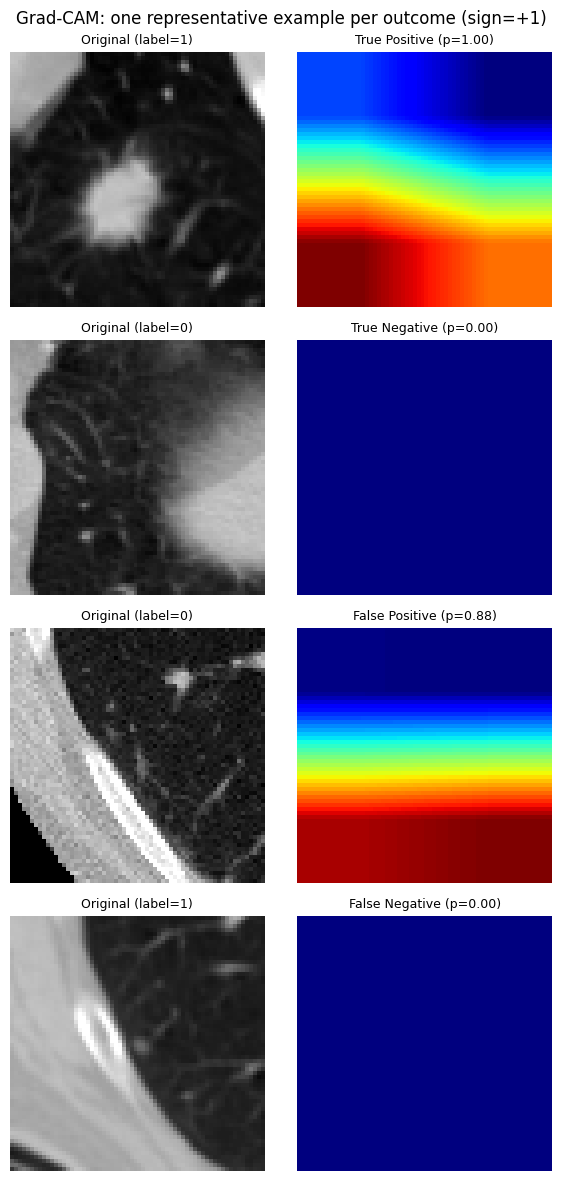

In [14]:
diagnostic_samples = {name: sample_indices(mask, GRADCAM_DIAGNOSTIC_SAMPLE_SIZE, rng_gradcam)
                      for name, mask in category_masks.items()}

print(f"Flat-map rate by category (sign=+1, 'evidence for nodule'), "
      f"n up to {GRADCAM_DIAGNOSTIC_SAMPLE_SIZE} per category:")
for cat_name, idxs in diagnostic_samples.items():
    n_flat = 0
    for idx in idxs:
        model_input = normalize_patch(torch.from_numpy(test_ds.patches[idx])).unsqueeze(0).to(DEVICE)
        _, stats_out = compute_gradcam(model, model_input, target_layer, sign=1)
        n_flat += stats_out["degenerate_flat_map"]
    print(f"  {cat_name}: {n_flat}/{len(idxs)} flat")

illustrative_idx = {name: (idxs[0] if len(idxs) > 0 else None)
                    for name, idxs in diagnostic_samples.items()}

fig, axes = plt.subplots(4, 2, figsize=(6, 12))
for row, (cat_name, idx) in enumerate(illustrative_idx.items()):
    if idx is None:
        axes[row, 0].axis("off")
        axes[row, 1].axis("off")
        continue
    raw_patch = test_ds.patches[idx]
    model_input = normalize_patch(torch.from_numpy(raw_patch)).unsqueeze(0).to(DEVICE)
    heatmap, stats_out = compute_gradcam(model, model_input, target_layer, sign=1)
    label, prob = int(test_targets[idx]), float(test_probs[idx])
    print(f"[{cat_name}] idx={idx} label={label} p={prob:.3f} | {stats_out}")
    plot_gradcam_row(
        axes[row], raw_patch, heatmap,
        left_title=f"Original (label={label})",
        right_title=f"{cat_name} (p={prob:.2f})",
    )
plt.suptitle("Grad-CAM: one representative example per outcome (sign=+1)")
plt.tight_layout()
plt.show()

## 14. What Drove the Negative Calls (sign=-1)
#
A flat sign=+1 map only says the model found no evidence FOR a nodule —
it says nothing about what evidence, if any, drove the negative call.
This asks that question on the same two illustrative TN/FN examples.
One real limitation worth flagging: this technique can still miss a
case where a False Positive's map is flat *despite* being above
threshold — crossing the threshold means the summed contribution across
all 512 channels was net positive, yet GAP-based Grad-CAM only shows
spatial locations whose *individual* contribution was positive after
ReLU, so it can fail to explain calls driven by many small distributed
contributions.

[True Negative] idx=156 sign=-1 | {'logit': -8.745948791503906, 'pre_relu_max': 2.331592321395874, 'degenerate_flat_map': False}
[False Negative] idx=187 sign=-1 | {'logit': -5.83146858215332, 'pre_relu_max': 1.6492688655853271, 'degenerate_flat_map': False}


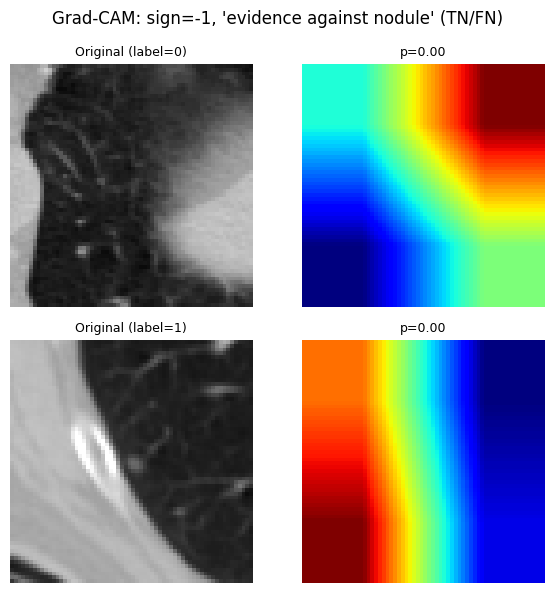

In [15]:
neg_categories = [c for c in ["True Negative", "False Negative"] if illustrative_idx[c] is not None]

if neg_categories:
    fig2, axes2 = plt.subplots(len(neg_categories), 2, figsize=(6, 3 * len(neg_categories)))
    if len(neg_categories) == 1:
        axes2 = axes2.reshape(1, -1)
    for row, cat_name in enumerate(neg_categories):
        idx = illustrative_idx[cat_name]
        raw_patch = test_ds.patches[idx]
        model_input = normalize_patch(torch.from_numpy(raw_patch)).unsqueeze(0).to(DEVICE)
        heatmap, stats_out = compute_gradcam(model, model_input, target_layer, sign=-1)
        label, prob = int(test_targets[idx]), float(test_probs[idx])
        print(f"[{cat_name}] idx={idx} sign=-1 | {stats_out}")
        plot_gradcam_row(
            axes2[row], raw_patch, heatmap,
            left_title=f"Original (label={label})",
            right_title=f"p={prob:.2f}",
        )
    plt.suptitle("Grad-CAM: sign=-1, 'evidence against nodule' (TN/FN)")
    plt.tight_layout()
    plt.show()
else:
    print("No TN/FN examples available -- nothing to show for sign=-1.")